# Forecasting Upgrade Lab

This notebook is isolated from the production package and focuses on **model inspection + enhanced-model experiments**.

Implemented upgrades in this notebook:
- strict 30-minute regularization and conservative imputation
- richer engineered features (cyclical time, tariff peak, extended lags, volatility)
- standardized Ridge with alpha tuning via time-based CV
- hybrid recursive + seasonal component blending
- site-local linear calibration
- leave-one-site-out and rolling-origin evaluation
- peak-focused metrics (precision, recall, MD error)
- peak-prioritized overlay candidate (`enhanced_peak_priority`)

Reference note: `ESUM_T_Rex_Model_Building.ipynb` is reference only; it is not the active source of truth because it predicts `Gross Load` and uses features that are not available for future `kw_import` forecasting.

## Run Notes
1. Run cells from top to bottom.
2. The notebook reads the four workbook files from the repository root.
3. No production module is modified; this is an experiment-only workspace.

In [27]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable
import os
import warnings
import sys

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def _ensure_repo_root_on_path(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "trex_energy").exists():
            root = str(candidate)
            if root not in sys.path:
                sys.path.insert(0, root)
            return candidate
    raise ModuleNotFoundError("Could not locate repository root containing 'trex_energy'.")


REPO_ROOT = _ensure_repo_root_on_path(Path.cwd().resolve())

from trex_energy.ingestion import load_site_workbook

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")

In [28]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "trex_energy").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root containing trex_energy/")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
DATA_FILES = [
    REPO_ROOT / "1. Load Profile (With Solar Installed) SoL.xlsx",
    REPO_ROOT / "2. Load Profile (No Solar) E.xlsx",
    REPO_ROOT / "3. Load Profile (No Solar) SuN.xlsx",
    REPO_ROOT / "4. Load Profile (With Solar) Mi2.xlsx",
]

missing = [path.name for path in DATA_FILES if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing workbook files: {missing}")

raw_datasets: dict[str, pd.DataFrame] = {}
for path in DATA_FILES:
    frame, metadata = load_site_workbook(path)
    raw_datasets[metadata.site_id] = frame

print(f"Repository root: {REPO_ROOT}")
print(f"Loaded {len(raw_datasets)} site datasets")
list(raw_datasets.keys())

Repository root: C:\Users\User\Documents\TREX
Loaded 4 site datasets


['1. Load Profile (With Solar Installed) SoL',
 '2. Load Profile (No Solar) E',
 '3. Load Profile (No Solar) SuN',
 '4. Load Profile (With Solar) Mi2']

In [29]:
CANONICAL_COLUMNS = [
    "site_id",
    "interval_start",
    "interval_end",
    "kw_import",
    "kw_export",
    "kvar_import",
    "kvar_export",
    "has_solar",
    "existing_pv_kwp",
    "source_file",
    "source_sheet",
    "is_imputed",
]

POWER_COLUMNS = ["kw_import", "kw_export", "kvar_import", "kvar_export"]


def regularize_to_30min(frame: pd.DataFrame) -> pd.DataFrame:
    ordered = frame.sort_values("interval_end").drop_duplicates("interval_end", keep="last").copy()
    ordered = ordered.set_index("interval_end")

    full_index = pd.date_range(ordered.index.min(), ordered.index.max(), freq="30min")
    regular = ordered.reindex(full_index)
    regular.index.name = "interval_end"

    site_id = str(frame["site_id"].iloc[0])
    has_solar = bool(frame["has_solar"].iloc[0])
    source_file = str(frame["source_file"].iloc[0])
    existing_pv_candidates = frame["existing_pv_kwp"].dropna()
    existing_pv_kwp = float(existing_pv_candidates.iloc[0]) if not existing_pv_candidates.empty else np.nan

    regular["site_id"] = site_id
    regular["has_solar"] = has_solar
    regular["existing_pv_kwp"] = existing_pv_kwp
    regular["source_file"] = source_file
    regular["source_sheet"] = regular["source_sheet"].fillna("imputed")
    regular["interval_start"] = regular.index - pd.Timedelta(minutes=30)

    was_missing = regular["kw_import"].isna()
    for col in POWER_COLUMNS:
        series = pd.to_numeric(regular[col], errors="coerce")
        series = series.interpolate(method="time", limit=4, limit_direction="both")
        median = float(np.nanmedian(series.to_numpy()))
        if np.isnan(median):
            median = 0.0
        regular[col] = series.fillna(median).clip(lower=0.0)

    regular["is_imputed"] = was_missing
    regular = regular.reset_index()
    regular = regular[CANONICAL_COLUMNS]
    return regular


clean_datasets = {site_id: regularize_to_30min(frame) for site_id, frame in raw_datasets.items()}

quality_rows = []
for site_id, frame in clean_datasets.items():
    deltas = frame["interval_end"].diff().dropna()
    quality_rows.append(
        {
            "site_id": site_id,
            "rows": len(frame),
            "imputed_rows": int(frame["is_imputed"].sum()),
            "gap_count_after_regularization": int((deltas != pd.Timedelta(minutes=30)).sum()),
            "duplicate_count_after_regularization": int(frame["interval_end"].duplicated().sum()),
        }
    )

pd.DataFrame(quality_rows).sort_values("site_id")

,site_id,rows,imputed_rows,gap_count_after_regularization,duplicate_count_after_regularization
0,1. Load Profile (With Solar Installed) SoL,2928,141,0,0
1,2. Load Profile (No Solar) E,2928,0,0,0
2,3. Load Profile (No Solar) SuN,2832,65,0,0
3,4. Load Profile (With Solar) Mi2,2928,0,0,0


## Enhanced Feature Engineering

This block adds upgrades in the enhanced model:
- cyclical time encoding
- tariff peak and daylight indicators
- extended lag set
- rolling mean/std/max for short and daily windows
- solar interaction term

In [30]:
from notebooks.model_upgrade_inspection.forecast_model_upgrade_support import (
    LAG_WINDOWS,
    ROLL_WINDOWS,
    add_enhanced_features,
)

sample_site_id = sorted(clean_datasets.keys())[0]
sample_prepared, sample_features = add_enhanced_features(clean_datasets[sample_site_id])
print(f"Sample site: {sample_site_id}")
print(f"Prepared rows: {len(sample_prepared):,}")
print(f"Feature count: {len(sample_features)}")
sample_prepared[sample_features + ["kw_import"]].head(3)


Sample site: 1. Load Profile (With Solar Installed) SoL
Prepared rows: 2,256
Feature count: 54


,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_weekend,is_monday,is_post_weekend,weekday_daylight,tariff_peak,daylight,has_solar_int,solar_daylight_interaction,solar_weekday_daylight_interaction,solar_post_weekend_interaction,morning_ramp_indicator,afternoon_decline_indicator,daylight_progress,solar_daylight_progress,solar_hour_sin_interaction,solar_hour_cos_interaction,solar_tariff_peak_interaction,solar_morning_ramp_interaction,solar_afternoon_decline_interaction,lag_1,lag_2,lag_3,lag_6,lag_24,lag_48,lag_96,lag_336,lag_672,rolling_mean_4,rolling_mean_24,rolling_mean_48,rolling_std_4,rolling_std_24,rolling_std_48,rolling_max_4,rolling_max_24,rolling_max_48,delta_lag_1_2,delta_lag_2_3,delta_lag_1_48,delta_lag_1_336,same_slot_prev_day_delta,same_slot_prev_week_delta,same_slot_day_vs_week_gap,rolling_delta_mean_4,rolling_delta_std_4,rolling_delta_mean_24,rolling_delta_std_24,kw_import
0,0.130526,0.991445,0.0,1.0,-1.0,-1.836970e-16,0,1,1,0,0,0,1,0,0,1,0,0,0.0,0.0,0.0,0.0,0,0,0,68.0,66.0,67.0,67.0,67.0,65.0,612.0,87.0,74.0,67.0,67.083333,65.416667,0.816497,1.639636,2.719773,68.0,69.0,69.0,2.0,-1.0,3.0,-19.0,-547.0,13.0,-22.0,0.0,1.414214,-4.736952e-15,1.444630,65.0
1,0.258819,0.965926,0.0,1.0,-1.0,-1.836970e-16,0,1,1,0,0,0,1,0,0,1,0,0,0.0,0.0,0.0,0.0,0,0,0,65.0,68.0,66.0,68.0,69.0,66.0,638.0,89.0,74.0,66.5,67.000000,65.416667,1.290994,1.693979,2.719773,68.0,69.0,69.0,-3.0,2.0,-1.0,-24.0,-572.0,15.0,-23.0,-0.5,2.081666,-8.333333e-02,1.558055,67.0
2,0.382683,0.923880,0.0,1.0,-1.0,-1.836970e-16,0,1,1,0,0,0,1,0,0,1,0,0,0.0,0.0,0.0,0.0,0,0,0,67.0,65.0,68.0,67.0,69.0,66.0,644.0,82.0,73.0,66.5,66.916667,65.437500,1.290994,1.639636,2.728153,68.0,69.0,69.0,2.0,-3.0,1.0,-15.0,-578.0,9.0,-16.0,0.0,2.449490,-8.333333e-02,1.558055,67.0


In [31]:
import importlib
from notebooks.model_upgrade_inspection import forecast_model_upgrade_support as forecast_support

forecast_support = importlib.reload(forecast_support)

TrainedRidge = forecast_support.TrainedRidge
build_training_rows = forecast_support.build_training_rows
fit_global_enhanced_ridge = forecast_support.fit_global_enhanced_ridge
tune_ridge_alpha = forecast_support.tune_ridge_alpha


In [32]:
import importlib
from notebooks.model_upgrade_inspection import forecast_model_upgrade_support as forecast_support

forecast_support = importlib.reload(forecast_support)

TrainedRidge = forecast_support.TrainedRidge
build_cutoffs = forecast_support.build_cutoffs
build_training_rows = forecast_support.build_training_rows
enhanced_feature_row = forecast_support.enhanced_feature_row
evaluate_forecast = forecast_support.evaluate_forecast
evaluate_forecast_components = forecast_support.evaluate_forecast_components
LateHorizonPeakEnvelope = forecast_support.LateHorizonPeakEnvelope
MdPeakCalibration = forecast_support.MdPeakCalibration
PeakAlertPolicy = forecast_support.PeakAlertPolicy
apply_peak_risk_overlay = forecast_support.apply_peak_risk_overlay
apply_late_horizon_peak_uplift = forecast_support.apply_late_horizon_peak_uplift
apply_md_peak_calibration = forecast_support.apply_md_peak_calibration
compare_peak_alert_policies = forecast_support.compare_peak_alert_policies
fit_peak_risk_overlay = forecast_support.fit_peak_risk_overlay
fit_late_horizon_peak_envelope = forecast_support.fit_late_horizon_peak_envelope
fit_direct_horizon_boosted_model = forecast_support.fit_direct_horizon_boosted_model
fit_direct_horizon_lightgbm_quantile_model = forecast_support.fit_direct_horizon_lightgbm_quantile_model
fit_md_peak_calibration = forecast_support.fit_md_peak_calibration
fit_global_enhanced_ridge = forecast_support.fit_global_enhanced_ridge
fit_horizon_residual_adjustment = forecast_support.fit_horizon_residual_adjustment
fit_regime_calibration = forecast_support.fit_regime_calibration
fit_site_calibration = forecast_support.fit_site_calibration
forecast_with_enhanced_model = forecast_support.forecast_with_enhanced_model
forecast_with_direct_horizon_boosted_model = forecast_support.forecast_with_direct_horizon_boosted_model
forecast_with_direct_horizon_lightgbm_quantile_model = forecast_support.forecast_with_direct_horizon_lightgbm_quantile_model
normalize_site_frame = forecast_support.normalize_site_frame
seasonal_anchor_prediction = forecast_support.seasonal_anchor_prediction
select_blend_weight = forecast_support.select_blend_weight
select_regime_blend_weight = forecast_support.select_regime_blend_weight
site_evaluation_settings = forecast_support.site_evaluation_settings
site_scale_from_frame = forecast_support.site_scale_from_frame
should_use_segmented_training = forecast_support.should_use_segmented_training
summarize_model_metrics = forecast_support.summarize_model_metrics
summarize_rolling_error_diagnostics = forecast_support.summarize_rolling_error_diagnostics
summarize_rolling_candidate_error_diagnostics = forecast_support.summarize_rolling_candidate_error_diagnostics
summarize_prediction_errors = forecast_support.summarize_prediction_errors
confirm_peak_alerts = forecast_support.confirm_peak_alerts
confirmed_alert_quantile = forecast_support.confirmed_alert_quantile
rank_alert_episodes = forecast_support.rank_alert_episodes
tune_ridge_alpha = forecast_support.tune_ridge_alpha

ENABLE_SEGMENTED_TRAINING = False
SEGMENTED_MIN_SITES_PER_SEGMENT = 2

EXPERIMENT_VARIANTS = {
    "A": {
        "label": "global_regime_current",
        "component_model": "enhanced",
    },
    "B": {
        "label": "global_regime_softened",
        "component_model": "enhanced",
        "forecast_overrides": {
            "solar_daytime_floor_ratio": 0.68,
            "solar_daytime_up_ratio": 0.40,
            "solar_monday_step_up_bonus": 0.05,
        },
        "inner_forecast_overrides": {
            "inner_solar_daytime_floor_ratio": 0.68,
            "inner_solar_daytime_up_ratio": 0.40,
            "inner_solar_monday_step_up_bonus": 0.05,
        },
    },
    "C": {
        "label": "seasonal_anchor_baseline",
        "component_model": "seasonal",
    },
}

def variant_bundle(base_settings: dict[str, object], variant_key: str) -> dict[str, object]:
    variant = EXPERIMENT_VARIANTS[variant_key]
    return {
        "label": variant["label"],
        "component_model": variant.get("component_model", "enhanced"),
        "fit_kwargs": {
            "enable_segmented_training": variant.get("enable_segmented_training", ENABLE_SEGMENTED_TRAINING),
            "segmented_min_sites_per_segment": variant.get(
                "segmented_min_sites_per_segment",
                SEGMENTED_MIN_SITES_PER_SEGMENT,
            ),
        },
        "forecast_kwargs": {
            **base_settings["forecast_kwargs"],
            **variant.get("forecast_overrides", {}),
        },
        "inner_forecast_kwargs": {
            **base_settings["inner_forecast_kwargs"],
            **variant.get("inner_forecast_overrides", {}),
        },
    }


In [33]:
FORECAST_REPORT_COLUMNS = forecast_support.FORECAST_METRIC_COLUMNS
PEAK_ALERT_QUANTILE = 0.80
PEAK_MATCH_WINDOW = 2
LATE_PEAK_UPLIFT_START_STEP = 33
LATE_PEAK_UPLIFT_SCORE_QUANTILE = 0.80
LATE_PEAK_UPLIFT_FLOOR_RATIO = 0.88
LATE_PEAK_UPLIFT_MAX_KW = 250.0
DIRECT_HGB_MAX_ITER = 80
DIRECT_LGBM_N_ESTIMATORS = 10
DIRECT_LGBM_RECENT_ROWS = 1200
PEAK_ALERT_POLICIES = {
    "strict_15pct": PeakAlertPolicy(alert_quantile=0.85, match_window_intervals=2, score_smoothing_window=1),
    "current_20pct": PeakAlertPolicy(alert_quantile=0.80, match_window_intervals=2, score_smoothing_window=1),
    "catch_more_25pct": PeakAlertPolicy(alert_quantile=0.75, match_window_intervals=2, score_smoothing_window=1),
    "smoothed_20pct": PeakAlertPolicy(alert_quantile=0.80, match_window_intervals=2, score_smoothing_window=3),
}


## Evaluation 1: Leave-One-Site-Out (Enhanced Only)

For each site, train on the other 3 sites and forecast the held-out site's next 48 intervals.
This section evaluates only the enhanced model.

In [34]:
HORIZON = 48
COMPARISON_HORIZON = 96
site_ids = sorted(clean_datasets.keys())

loso_rows = []
loso_model_rows = []
alpha_rows = []
best_predictions: dict[str, pd.DataFrame] = {}
comparison_48h_rows = []
comparison_48h_model_rows = []

for holdout_site in site_ids:
    full_target = clean_datasets[holdout_site].sort_values("interval_end").reset_index(drop=True)
    target_has_solar = bool(full_target["has_solar"].iloc[0])
    settings = site_evaluation_settings(target_has_solar)
    active_variant = variant_bundle(settings, "B" if target_has_solar else "A")

    train_frames = [clean_datasets[s] for s in site_ids if s != holdout_site]

    enhanced = fit_global_enhanced_ridge(
        train_frames,
        alpha_grid=settings["alpha_grid"],
        n_splits=4,
        normalize_targets=True,
        **active_variant["fit_kwargs"],
    )
    alpha_rows.append({"site_id": holdout_site, "selected_alpha": enhanced.alpha})

    target_train = full_target.iloc[:-HORIZON].copy()
    target_actual = full_target.iloc[-HORIZON:]["kw_import"].to_numpy()
    target_scale = site_scale_from_frame(target_train)

    calibration = fit_site_calibration(
        enhanced.model,
        target_train,
        enhanced.feature_columns,
        window=336,
        normalize_targets=enhanced.normalize_targets,
        site_scale=target_scale,
    )
    regime_calibration = fit_regime_calibration(
        enhanced.model,
        target_train,
        enhanced.feature_columns,
        window=336,
        normalize_targets=enhanced.normalize_targets,
        site_scale=target_scale,
    )
    blend_weight, _ = select_blend_weight(
        enhanced.model,
        target_train,
        enhanced.feature_columns,
        horizon=HORIZON,
        candidates=settings["blend_candidates"],
        normalize_targets=enhanced.normalize_targets,
        site_scale=target_scale,
        **active_variant["inner_forecast_kwargs"],
    )
    regime_blend_weight, _ = select_regime_blend_weight(
        enhanced.model,
        target_train,
        enhanced.feature_columns,
        horizon=HORIZON,
        candidates=settings["blend_candidates"],
        normalize_targets=enhanced.normalize_targets,
        site_scale=target_scale,
        default_weight=blend_weight,
        **active_variant["inner_forecast_kwargs"],
    )
    enhanced_forecast = forecast_with_enhanced_model(
        model=enhanced.model,
        feature_columns=enhanced.feature_columns,
        target_frame=target_train,
        horizon=HORIZON,
        blend_weight=regime_blend_weight,
        calibration=regime_calibration,
        normalize_targets=enhanced.normalize_targets,
        site_scale=target_scale,
        **active_variant["forecast_kwargs"],
    )
    peak_overlay_prepared, _ = add_enhanced_features(target_train)
    peak_overlay = fit_peak_risk_overlay(peak_overlay_prepared, enhanced.feature_columns)
    enhanced_forecast = apply_peak_risk_overlay(enhanced_forecast, peak_overlay, target_train)
    # enhanced_peak_priority is added by evaluate_forecast_components when peak_risk_overlay_score is present.
    component_metrics = evaluate_forecast_components(
        target_actual,
        enhanced_forecast,
        peak_match_window=PEAK_MATCH_WINDOW,
        overlay_alert_quantile=PEAK_ALERT_QUANTILE,
    )
    enhanced_metrics = next(
        row for row in component_metrics.to_dict(orient="records") if row["model"] == "enhanced"
    )

    loso_rows.append(
        {
            "site_id": holdout_site,
            "model": "enhanced",
            "blend_weight": blend_weight,
            "calibration_intercept": calibration[0],
            "calibration_slope": calibration[1],
            **enhanced_metrics,
        }
    )

    for metrics in component_metrics.to_dict(orient="records"):
        loso_model_rows.append(
            {
                "site_id": holdout_site,
                "model": metrics["model"],
                "blend_weight": blend_weight if metrics["model"] == "enhanced" else np.nan,
                "calibration_intercept": calibration[0] if metrics["model"] == "enhanced" else np.nan,
                "calibration_slope": calibration[1] if metrics["model"] == "enhanced" else np.nan,
                **{key: value for key, value in metrics.items() if key != "model"},
            }
        )

    comparison_train = full_target.iloc[:-COMPARISON_HORIZON].copy()
    comparison_actual = full_target.iloc[-COMPARISON_HORIZON:]["kw_import"].to_numpy()
    comparison_scale = site_scale_from_frame(comparison_train)
    comparison_calibration = fit_site_calibration(
        enhanced.model,
        comparison_train,
        enhanced.feature_columns,
        window=336,
        normalize_targets=enhanced.normalize_targets,
        site_scale=comparison_scale,
    )
    comparison_regime_calibration = fit_regime_calibration(
        enhanced.model,
        comparison_train,
        enhanced.feature_columns,
        window=336,
        normalize_targets=enhanced.normalize_targets,
        site_scale=comparison_scale,
    )
    comparison_forecast = forecast_with_enhanced_model(
        model=enhanced.model,
        feature_columns=enhanced.feature_columns,
        target_frame=comparison_train,
        horizon=COMPARISON_HORIZON,
        blend_weight=regime_blend_weight,
        calibration=comparison_regime_calibration,
        normalize_targets=enhanced.normalize_targets,
        site_scale=comparison_scale,
        **active_variant["forecast_kwargs"],
    )
    comparison_peak_overlay_prepared, _ = add_enhanced_features(comparison_train)
    comparison_peak_overlay = fit_peak_risk_overlay(comparison_peak_overlay_prepared, enhanced.feature_columns)
    comparison_forecast = apply_peak_risk_overlay(comparison_forecast, comparison_peak_overlay, comparison_train)
    comparison_component_metrics = evaluate_forecast_components(
        comparison_actual,
        comparison_forecast,
        peak_match_window=PEAK_MATCH_WINDOW,
        overlay_alert_quantile=PEAK_ALERT_QUANTILE,
    )
    comparison_metrics = next(
        row for row in comparison_component_metrics.to_dict(orient="records") if row["model"] == "enhanced"
    )

    best_predictions[holdout_site] = pd.DataFrame(
        {
            "interval_end": full_target.iloc[-COMPARISON_HORIZON:]["interval_end"].to_numpy(),
            "actual_kw_import": comparison_actual,
            "enhanced_kw_import": comparison_forecast["forecast_kw_import"].to_numpy(),
            "ridge_only_kw_import": comparison_forecast["ridge_component"].to_numpy(),
            "seasonal_kw_import": comparison_forecast["seasonal_component"].to_numpy(),
        }
    )
    comparison_48h_rows.append(
        {
            "site_id": holdout_site,
            "hours": COMPARISON_HORIZON / 2,
            **comparison_metrics,
        }
    )
    for metrics in comparison_component_metrics.to_dict(orient="records"):
        comparison_48h_model_rows.append(
            {
                "site_id": holdout_site,
                "hours": COMPARISON_HORIZON / 2,
                **metrics,
            }
        )

loso_results = pd.DataFrame(loso_rows).sort_values(["site_id"]).reset_index(drop=True)
loso_model_results = pd.DataFrame(loso_model_rows).sort_values(["site_id", "model"]).reset_index(drop=True)
comparison_48h_results = pd.DataFrame(comparison_48h_rows).sort_values(["site_id"]).reset_index(drop=True)
comparison_48h_model_results = pd.DataFrame(comparison_48h_model_rows).sort_values(["site_id", "model"]).reset_index(drop=True)
alpha_summary = pd.DataFrame(alpha_rows).sort_values("site_id").reset_index(drop=True)

print("Selected alpha by held-out site:")
display(alpha_summary)
print("LOSO enhanced-model metrics:")
display(loso_results)
print("48-hour LOSO comparison metrics:")
display(comparison_48h_results)
print("48-hour LOSO model comparison (enhanced vs ridge_only vs seasonal):")
display(
    comparison_48h_model_results[["site_id", "hours", "model", *FORECAST_REPORT_COLUMNS]]
)


Selected alpha by held-out site:


,site_id,selected_alpha
0,1. Load Profile (With Solar Installed) SoL,30.0
1,2. Load Profile (No Solar) E,100.0
2,3. Load Profile (No Solar) SuN,30.0
3,4. Load Profile (With Solar) Mi2,3.0


LOSO enhanced-model metrics:


,site_id,model,blend_weight,calibration_intercept,calibration_slope,mae_kw,rmse_kw,mean_error_kw,wape_pct,smape_pct,mape_pct,nrmse_by_median_pct,nrmse_by_peak_pct,peak_precision,peak_recall,peak_f1,peak_false_negative_count,peak_false_positive_count,peak_capture_rate_at_k,md_peak_rank,peak_time_error_intervals,md_abs_error_kw
0,1. Load Profile (With Solar Installed) SoL,enhanced,0.65,-0.002871,1.010146,35.752851,43.875549,-26.771701,4.775802,4.607997,4.509649,6.438085,4.702631,0.6,0.6,0.6,2.0,0.0,0.4,13.0,4.0,49.070094
1,2. Load Profile (No Solar) E,enhanced,0.30,0.012880,1.005590,129.595723,141.777685,6.027535,18.277052,18.618109,18.902565,20.311989,15.410618,0.6,0.6,0.6,2.0,4.0,0.0,27.0,31.0,3.613969
2,3. Load Profile (No Solar) SuN,enhanced,0.39,-0.013582,0.989941,47.219101,67.994914,39.275276,52.001760,35.163164,53.414530,112.897090,45.345838,0.2,0.2,0.2,4.0,4.0,0.0,9.0,8.0,113.259834
3,4. Load Profile (With Solar) Mi2,enhanced,0.20,0.032313,0.900000,103.194992,134.856921,16.542318,10.099210,10.822056,11.751743,12.935916,9.667163,0.2,0.2,0.2,4.0,4.0,0.0,17.0,31.0,76.863760


48-hour LOSO comparison metrics:


,site_id,hours,model,mae_kw,rmse_kw,mean_error_kw,wape_pct,smape_pct,mape_pct,nrmse_by_median_pct,nrmse_by_peak_pct,peak_precision,peak_recall,peak_f1,peak_false_negative_count,peak_false_positive_count,peak_capture_rate_at_k,md_peak_rank,peak_time_error_intervals,md_abs_error_kw
0,1. Load Profile (With Solar Installed) SoL,48.0,enhanced,49.768893,59.005678,-42.034565,6.599737,6.551338,6.301051,8.588890,6.146425,0.8,0.8,0.8,2.0,1.0,0.6,3.0,2.0,80.090896
1,2. Load Profile (No Solar) E,48.0,enhanced,109.464836,139.347546,-62.029145,15.161335,16.596445,15.245365,19.571285,14.606661,0.6,0.6,0.6,4.0,3.0,0.3,1.0,0.0,70.391605
2,3. Load Profile (No Solar) SuN,48.0,enhanced,31.202159,45.842134,8.503397,25.763396,24.257251,30.198070,65.379962,14.888402,1.0,1.0,1.0,0.0,0.0,0.6,14.0,8.0,36.864036
3,4. Load Profile (With Solar) Mi2,48.0,enhanced,129.823327,162.270942,-24.050446,12.443130,13.094374,13.560029,15.476485,11.387434,0.9,0.9,0.9,1.0,2.0,0.6,20.0,4.0,113.968814


48-hour LOSO model comparison (enhanced vs ridge_only vs seasonal):


,site_id,hours,model,mae_kw,rmse_kw,mean_error_kw,wape_pct,smape_pct,mape_pct,nrmse_by_median_pct,nrmse_by_peak_pct,peak_precision,peak_recall,peak_f1,peak_false_negative_count,peak_false_positive_count,peak_capture_rate_at_k,md_peak_rank,peak_time_error_intervals,md_abs_error_kw
0,1. Load Profile (With Solar Installed) SoL,48.0,enhanced,49.768893,59.005678,-42.034565,6.599737,6.551338,6.301051,8.588890,6.146425,0.80,0.8,0.800000,2.0,1.0,0.6,3.0,2.0,80.090896
1,1. Load Profile (With Solar Installed) SoL,48.0,enhanced_peak_priority,49.768893,59.005678,-42.034565,6.599737,6.551338,6.301051,8.588890,6.146425,0.45,0.9,0.600000,1.0,2.0,0.5,2.0,2.0,80.090896
2,1. Load Profile (With Solar Installed) SoL,48.0,ridge_only,61.339530,79.958300,-45.922495,8.134092,8.190231,7.800096,11.638763,8.328990,0.80,0.8,0.800000,2.0,1.0,0.6,4.0,1.0,3.080524
3,1. Load Profile (With Solar Installed) SoL,48.0,seasonal,31.893303,39.558252,-24.436551,4.229297,4.436528,4.303143,5.758115,4.120651,0.70,0.7,0.700000,3.0,1.0,0.5,3.0,2.0,46.200000
4,2. Load Profile (No Solar) E,48.0,enhanced,109.464836,139.347546,-62.029145,15.161335,16.596445,15.245365,19.571285,14.606661,0.60,0.6,0.600000,4.0,3.0,0.3,1.0,0.0,70.391605
5,2. Load Profile (No Solar) E,48.0,enhanced_peak_priority,109.464836,139.347546,-62.029145,15.161335,16.596445,15.245365,19.571285,14.606661,0.40,0.8,0.533333,2.0,3.0,0.6,2.0,0.0,70.391605
6,2. Load Profile (No Solar) E,48.0,ridge_only,146.991975,185.214171,-100.867568,20.358999,23.770388,20.503292,26.013226,19.414483,0.80,0.8,0.800000,2.0,2.0,0.4,2.0,4.0,23.653121
7,2. Load Profile (No Solar) E,48.0,seasonal,101.082916,123.071341,-39.409248,14.000404,14.867789,14.105377,17.285301,12.900560,0.80,0.8,0.800000,2.0,1.0,0.5,10.0,4.0,37.600000
8,3. Load Profile (No Solar) SuN,48.0,enhanced,31.202159,45.842134,8.503397,25.763396,24.257251,30.198070,65.379962,14.888402,1.00,1.0,1.000000,0.0,0.0,0.6,14.0,8.0,36.864036
9,3. Load Profile (No Solar) SuN,48.0,enhanced_peak_priority,31.202159,45.842134,8.503397,25.763396,24.257251,30.198070,65.379962,14.888402,0.50,1.0,0.666667,0.0,4.0,0.5,14.0,8.0,36.864036


In [35]:
rolling_rows = []
rolling_model_rows = []
rolling_prediction_rows = []
peak_policy_rows = []
alert_episode_rows = []
md_peak_history = {site_id: {"actual": [], "predicted": []} for site_id in site_ids}

for site_id, frame in clean_datasets.items():
    ordered = frame.sort_values("interval_end").reset_index(drop=True)
    cutoffs = build_cutoffs(len(ordered), horizon=HORIZON)
    site_has_solar = bool(ordered["has_solar"].iloc[0])
    settings = site_evaluation_settings(site_has_solar)
    active_variant = variant_bundle(settings, "B" if site_has_solar else "A")

    for fold_number, cutoff in enumerate(cutoffs, start=1):
        train_frame = ordered.iloc[:cutoff].copy()
        actual_slice = ordered.iloc[cutoff : cutoff + HORIZON].copy()
        actual = actual_slice["kw_import"].to_numpy()
        target_scale = site_scale_from_frame(train_frame)
        pooled_train_frames = [train_frame, *[clean_datasets[other_site] for other_site in site_ids if other_site != site_id]]

        enhanced = fit_global_enhanced_ridge(
            pooled_train_frames,
            alpha_grid=settings["alpha_grid"],
            n_splits=3,
            normalize_targets=True,
            **active_variant["fit_kwargs"],
        )

        calibration_intercept, calibration_slope = fit_site_calibration(
            enhanced.model,
            train_frame,
            enhanced.feature_columns,
            window=336,
            normalize_targets=enhanced.normalize_targets,
            site_scale=target_scale,
        )
        regime_calibration = fit_regime_calibration(
            enhanced.model,
            train_frame,
            enhanced.feature_columns,
            window=336,
            normalize_targets=enhanced.normalize_targets,
            site_scale=target_scale,
        )

        blend_weight, _ = select_blend_weight(
            enhanced.model,
            train_frame,
            enhanced.feature_columns,
            horizon=HORIZON,
            candidates=settings["blend_candidates"],
            use_calibration_in_inner=True,
            normalize_targets=enhanced.normalize_targets,
            site_scale=target_scale,
            **active_variant["inner_forecast_kwargs"],
        )
        enhanced_forecast = forecast_with_enhanced_model(
            model=enhanced.model,
            feature_columns=enhanced.feature_columns,
            target_frame=train_frame,
            horizon=HORIZON,
            blend_weight=blend_weight,
            calibration=regime_calibration,
            normalize_targets=enhanced.normalize_targets,
            site_scale=target_scale,
            **active_variant["forecast_kwargs"],
        )
        direct_hgb = fit_direct_horizon_boosted_model(
            pooled_train_frames,
            horizon=HORIZON,
            max_iter=DIRECT_HGB_MAX_ITER,
        )
        direct_hgb_forecast = forecast_with_direct_horizon_boosted_model(
            direct_hgb,
            train_frame,
            horizon=HORIZON,
            site_scale=target_scale,
        )
        direct_lgbm_train_frames = [train_frame.tail(DIRECT_LGBM_RECENT_ROWS).copy()]
        direct_lgbm_quantile = fit_direct_horizon_lightgbm_quantile_model(
            direct_lgbm_train_frames,
            horizon=HORIZON,
            n_estimators=DIRECT_LGBM_N_ESTIMATORS,
        )
        direct_lgbm_forecast = forecast_with_direct_horizon_lightgbm_quantile_model(
            direct_lgbm_quantile,
            train_frame,
            horizon=HORIZON,
            site_scale=target_scale,
        )
        peak_overlay_prepared, _ = add_enhanced_features(train_frame)
        peak_overlay = fit_peak_risk_overlay(peak_overlay_prepared, enhanced.feature_columns)
        enhanced_forecast = apply_peak_risk_overlay(enhanced_forecast, peak_overlay, train_frame)
        enhanced_pred = enhanced_forecast["forecast_kw_import"].to_numpy(dtype=float)
        site_peak_history = md_peak_history[site_id]
        md_calibration = (
            fit_md_peak_calibration(site_peak_history["actual"], site_peak_history["predicted"])
            if site_peak_history["actual"]
            else MdPeakCalibration(multiplier=1.0)
        )
        md_calibrated_forecast = apply_md_peak_calibration(enhanced_forecast, md_calibration)
        late_peak_envelope = fit_late_horizon_peak_envelope(train_frame)
        late_peak_uplift_forecast = apply_late_horizon_peak_uplift(
            enhanced_forecast,
            late_peak_envelope,
            start_step=LATE_PEAK_UPLIFT_START_STEP,
            score_quantile=LATE_PEAK_UPLIFT_SCORE_QUANTILE,
            floor_ratio=LATE_PEAK_UPLIFT_FLOOR_RATIO,
            max_uplift_kw=LATE_PEAK_UPLIFT_MAX_KW,
            has_solar=site_has_solar,
        )
        confirmed_forecast = confirm_peak_alerts(enhanced_forecast, alert_quantile=PEAK_ALERT_QUANTILE)
        confirmed_peak_quantile = confirmed_alert_quantile(confirmed_forecast["is_confirmed_peak_alert"])

        # enhanced_peak_priority is added by evaluate_forecast_components when peak_risk_overlay_score is present.
        component_metrics = evaluate_forecast_components(
            actual,
            enhanced_forecast,
            peak_match_window=PEAK_MATCH_WINDOW,
            overlay_alert_quantile=PEAK_ALERT_QUANTILE,
        )
        md_calibrated_metrics = evaluate_forecast(
            actual,
            md_calibrated_forecast["md_calibrated_kw_import"].to_numpy(dtype=float),
            peak_match_window=PEAK_MATCH_WINDOW,
        )
        late_peak_uplift_metrics = evaluate_forecast(
            actual,
            late_peak_uplift_forecast["late_peak_uplift_kw_import"].to_numpy(dtype=float),
            peak_match_window=PEAK_MATCH_WINDOW,
        )
        direct_hgb_metrics = evaluate_forecast(
            actual,
            direct_hgb_forecast["forecast_kw_import"].to_numpy(dtype=float),
            peak_match_window=PEAK_MATCH_WINDOW,
        )
        direct_lgbm_p50_metrics = evaluate_forecast(
            actual,
            direct_lgbm_forecast["forecast_p50_kw_import"].to_numpy(dtype=float),
            peak_match_window=PEAK_MATCH_WINDOW,
        )
        direct_lgbm_p90_metrics = evaluate_forecast(
            actual,
            direct_lgbm_forecast["forecast_p90_kw_import"].to_numpy(dtype=float),
            peak_match_window=PEAK_MATCH_WINDOW,
        )
        direct_lgbm_md_risk_metrics = evaluate_forecast(
            actual,
            direct_lgbm_forecast["forecast_p50_kw_import"].to_numpy(dtype=float),
            peak_score=direct_lgbm_forecast["md_risk_head_score"].to_numpy(dtype=float),
            predicted_peak_quantile=PEAK_ALERT_QUANTILE,
            peak_match_window=PEAK_MATCH_WINDOW,
        )
        component_records = component_metrics.to_dict(orient="records")
        component_records.append({"model": "direct_hgb", **direct_hgb_metrics})
        component_records.append({"model": "direct_lgbm_quantile_p50", **direct_lgbm_p50_metrics})
        component_records.append({"model": "direct_lgbm_quantile_p90", **direct_lgbm_p90_metrics})
        component_records.append({"model": "direct_lgbm_md_risk", **direct_lgbm_md_risk_metrics})
        component_records.append({"model": "enhanced_md_calibrated", **md_calibrated_metrics})
        component_records.append({"model": "enhanced_late_peak_uplift", **late_peak_uplift_metrics})
        confirmed_metrics = evaluate_forecast(
            actual,
            confirmed_forecast["forecast_kw_import"].to_numpy(dtype=float),
            peak_score=confirmed_forecast["confirmed_peak_score"].to_numpy(dtype=float),
            predicted_peak_quantile=confirmed_peak_quantile,
            peak_match_window=PEAK_MATCH_WINDOW,
        )
        component_records.append({"model": "enhanced_peak_confirmed", **confirmed_metrics})
        episode_table = rank_alert_episodes(confirmed_forecast)
        episode_table["site_id"] = site_id
        episode_table["fold"] = fold_number
        alert_episode_rows.extend(episode_table.to_dict("records"))
        policy_table = compare_peak_alert_policies(
            actual,
            enhanced_forecast,
            PEAK_ALERT_POLICIES,
            actual_peak_quantile=0.90,
        )
        policy_table["site_id"] = site_id
        policy_table["fold"] = fold_number
        policy_table["cutoff"] = cutoff
        peak_policy_rows.extend(policy_table.to_dict("records"))
        enhanced_metrics = next(
            row for row in component_records if row["model"] == "enhanced"
        )
        errors = enhanced_pred - actual
        drift_slope_kw_per_step = float(np.polyfit(np.arange(len(errors)), errors, 1)[0]) if len(errors) > 1 else 0.0
        cumulative_error_kw = float(np.sum(errors))
        overprediction_ratio = float(np.mean(errors > 0))
        mean_effective_blend = float(enhanced_forecast["effective_blend_weight"].mean())

        rolling_rows.append(
            {
                "site_id": site_id,
                "fold": fold_number,
                "model": "enhanced",
                "blend_weight": blend_weight,
                "mean_effective_blend_weight": mean_effective_blend,
                "selected_alpha": enhanced.alpha,
                "calibration_intercept": calibration_intercept,
                "calibration_slope": calibration_slope,
                "drift_slope_kw_per_step": drift_slope_kw_per_step,
                "cumulative_error_kw": cumulative_error_kw,
                "overprediction_ratio": overprediction_ratio,
                **enhanced_metrics,
            }
        )

        for metrics in component_records:
            rolling_model_rows.append(
                {
                    "site_id": site_id,
                    "fold": fold_number,
                    **metrics,
                }
            )
        site_peak_history["actual"].append(float(np.max(actual)))
        site_peak_history["predicted"].append(float(np.max(enhanced_pred)))

        fold_prediction = pd.DataFrame(
            {
                "site_id": site_id,
                "fold": fold_number,
                "interval_end": actual_slice["interval_end"].to_numpy(),
                "actual_kw_import": actual,
                "enhanced_kw_import": enhanced_pred,
                "direct_hgb_kw_import": direct_hgb_forecast["forecast_kw_import"].to_numpy(dtype=float),
                "direct_lgbm_p50_kw_import": direct_lgbm_forecast["forecast_p50_kw_import"].to_numpy(dtype=float),
                "direct_lgbm_p80_kw_import": direct_lgbm_forecast["forecast_p80_kw_import"].to_numpy(dtype=float),
                "direct_lgbm_p90_kw_import": direct_lgbm_forecast["forecast_p90_kw_import"].to_numpy(dtype=float),
                "direct_lgbm_md_risk_score": direct_lgbm_forecast["md_risk_head_score"].to_numpy(dtype=float),
                "late_peak_uplift_kw_import": late_peak_uplift_forecast["late_peak_uplift_kw_import"].to_numpy(dtype=float),
                "late_peak_uplift_applied": late_peak_uplift_forecast["late_peak_uplift_applied"].to_numpy(dtype=bool),
                "late_peak_envelope_floor_kw": late_peak_uplift_forecast["late_peak_envelope_floor_kw"].to_numpy(dtype=float),
                "peak_risk_overlay_score": enhanced_forecast["peak_risk_overlay_score"].to_numpy(dtype=float),
            }
        )
        fold_prediction["error_kw"] = fold_prediction["enhanced_kw_import"] - fold_prediction["actual_kw_import"]
        fold_prediction["step"] = np.arange(1, len(fold_prediction) + 1)
        fold_prediction["day_of_week"] = fold_prediction["interval_end"].dt.dayofweek
        fold_prediction["weekday_name"] = fold_prediction["interval_end"].dt.day_name()
        fold_prediction["is_weekend"] = fold_prediction["day_of_week"] >= 5
        fold_prediction["is_daylight"] = (
            (fold_prediction["interval_end"].dt.hour >= 6)
            & (fold_prediction["interval_end"].dt.hour < 18)
        )
        fold_prediction["has_solar"] = site_has_solar
        rolling_prediction_rows.append(fold_prediction)

rolling_results = pd.DataFrame(rolling_rows).sort_values(["site_id", "fold"]).reset_index(drop=True)
rolling_model_results = pd.DataFrame(rolling_model_rows).sort_values(["site_id", "fold", "model"]).reset_index(drop=True)
rolling_predictions = pd.concat(rolling_prediction_rows, ignore_index=True)
peak_policy_results = pd.DataFrame(peak_policy_rows)
alert_episode_summary = pd.DataFrame(alert_episode_rows)
rolling_summary = (
    rolling_results.groupby(["site_id"], as_index=False)
    .agg(
        fold_count=("fold", "nunique"),
        mae_kw=("mae_kw", "mean"),
        rmse_kw=("rmse_kw", "mean"),
        mean_error_kw=("mean_error_kw", "mean"),
        wape_pct=("wape_pct", "mean"),
        smape_pct=("smape_pct", "mean"),
        mape_pct=("mape_pct", "mean"),
        nrmse_by_median_pct=("nrmse_by_median_pct", "mean"),
        nrmse_by_peak_pct=("nrmse_by_peak_pct", "mean"),
        peak_precision=("peak_precision", "mean"),
        peak_recall=("peak_recall", "mean"),
        peak_f1=("peak_f1", "mean"),
        peak_false_negative_count=("peak_false_negative_count", "mean"),
        peak_false_positive_count=("peak_false_positive_count", "mean"),
        peak_capture_rate_at_k=("peak_capture_rate_at_k", "mean"),
        md_peak_rank=("md_peak_rank", "mean"),
        peak_time_error_intervals=("peak_time_error_intervals", "mean"),
        md_abs_error_kw=("md_abs_error_kw", "mean"),
        drift_slope_kw_per_step=("drift_slope_kw_per_step", "mean"),
        cumulative_error_kw=("cumulative_error_kw", "mean"),
        overprediction_ratio=("overprediction_ratio", "mean"),
        mean_effective_blend_weight=("mean_effective_blend_weight", "mean"),
    )
    .sort_values(["site_id"])
    .reset_index(drop=True)
)
rolling_model_summary = summarize_model_metrics(rolling_model_results, ["site_id", "model"])
rolling_model_summary = rolling_model_summary.merge(
    rolling_model_results.groupby(["site_id", "model"], as_index=False).agg(fold_count=("fold", "nunique")),
    on=["site_id", "model"],
    how="left",
)

rolling_predictions["period_type"] = np.where(rolling_predictions["is_weekend"], "weekend", "weekday")
rolling_predictions["light_regime"] = np.where(rolling_predictions["is_daylight"], "daylight", "night")
rolling_predictions["site_type"] = np.where(rolling_predictions["has_solar"], "solar", "non-solar")
rolling_error_diagnostics = summarize_rolling_error_diagnostics(rolling_predictions)
rolling_candidate_error_diagnostics = summarize_rolling_candidate_error_diagnostics(
    rolling_predictions,
    {
        "enhanced": "enhanced_kw_import",
        "direct_hgb": "direct_hgb_kw_import",
        "direct_lgbm_quantile_p50": "direct_lgbm_p50_kw_import",
        "direct_lgbm_quantile_p80": "direct_lgbm_p80_kw_import",
        "direct_lgbm_quantile_p90": "direct_lgbm_p90_kw_import",
        "enhanced_late_peak_uplift": "late_peak_uplift_kw_import",
    },
)

rolling_weekpart_summary = summarize_prediction_errors(rolling_predictions, ["site_id", "period_type"])
rolling_light_summary = summarize_prediction_errors(rolling_predictions, ["site_id", "light_regime"])
rolling_site_type_summary = summarize_prediction_errors(rolling_predictions, ["site_type"])
peak_policy_summary = (
    peak_policy_results.groupby("policy", as_index=False)[
        [
            "peak_precision",
            "peak_recall",
            "peak_f1",
            "peak_false_negative_count",
            "peak_false_positive_count",
            "md_peak_rank",
        ]
    ]
    .mean()
    .sort_values(["peak_recall", "peak_precision"], ascending=[False, False])
    .reset_index(drop=True)
)
rolling_weekday_coverage = (
    rolling_predictions.groupby(["site_id"], as_index=False)
    .agg(
        fold_count=("fold", "nunique"),
        weekday_count=("weekday_name", "nunique"),
        prediction_rows=("error_kw", "size"),
    )
    .sort_values(["site_id"])
    .reset_index(drop=True)
)

print("Rolling-origin enhanced-model fold metrics:")
display(rolling_results.head(20))
print("Rolling-origin enhanced-model summary (mean across folds):")
display(rolling_summary)
print("Rolling-origin model comparison (mean across folds):")
display(rolling_model_summary[["site_id", "model", "fold_count", *FORECAST_REPORT_COLUMNS]])
print("Rolling-origin weekday coverage summary:")
display(rolling_weekday_coverage)
print("Rolling-origin weekday vs weekend error summary:")
display(rolling_weekpart_summary)
print("Rolling-origin daylight vs night error summary:")
display(rolling_light_summary)
print("Rolling-origin solar vs non-solar error summary:")
display(rolling_site_type_summary)
print("Rolling-origin peak alert policy comparison:")
display(peak_policy_summary)
print("Rolling-origin error diagnostics:")
display(rolling_error_diagnostics)
print("Rolling-origin candidate error diagnostics:")
display(rolling_candidate_error_diagnostics)
print("Rolling-origin confirmed alert episode summary:")
display(alert_episode_summary)


Rolling-origin enhanced-model fold metrics:


,site_id,fold,model,blend_weight,mean_effective_blend_weight,selected_alpha,calibration_intercept,calibration_slope,drift_slope_kw_per_step,cumulative_error_kw,overprediction_ratio,mae_kw,rmse_kw,mean_error_kw,wape_pct,smape_pct,mape_pct,nrmse_by_median_pct,nrmse_by_peak_pct,peak_precision,peak_recall,peak_f1,peak_false_negative_count,peak_false_positive_count,peak_capture_rate_at_k,md_peak_rank,peak_time_error_intervals,md_abs_error_kw
0,1. Load Profile (With Solar Installed) SoL,1,enhanced,0.65,0.557934,10.00,-0.011126,1.011888,7.321373,-2773.383561,0.520833,116.742677,161.150031,-57.778824,17.137588,22.241274,18.634853,24.868832,18.716612,0.6,0.600000,0.600000,2.0,0.0,0.600000,3.0,2.0,55.270910
1,1. Load Profile (With Solar Installed) SoL,2,enhanced,0.65,0.557934,3.00,-0.010666,1.012335,0.639868,229.456017,0.625000,25.462066,36.125673,4.780334,3.679932,3.917961,4.035957,5.596541,3.991787,1.0,1.000000,1.000000,0.0,0.0,0.800000,5.0,1.0,18.426890
2,1. Load Profile (With Solar Installed) SoL,3,enhanced,0.65,0.557934,3.00,-0.010907,1.012879,-1.664126,-1028.786329,0.375000,45.623207,57.294516,-21.433049,6.437326,6.755446,6.594830,8.787502,6.234441,0.2,0.200000,0.200000,4.0,1.0,0.200000,7.0,7.0,26.367647
3,1. Load Profile (With Solar Installed) SoL,4,enhanced,0.65,0.557934,3.00,-0.010999,1.014222,8.952169,11260.181654,0.729167,245.578794,295.591503,234.587118,65.886659,62.546269,141.739883,79.997701,45.970685,0.0,0.000000,0.000000,5.0,5.0,0.000000,35.0,16.0,158.486057
4,1. Load Profile (With Solar Installed) SoL,5,enhanced,0.65,0.557934,3.00,-0.011836,1.014201,-7.150486,8371.747906,1.000000,174.411415,212.091107,174.411415,246.517901,94.061590,247.124763,300.838450,282.788143,0.4,0.181818,0.250000,9.0,0.0,0.181818,5.0,3.0,366.661945
5,1. Load Profile (With Solar Installed) SoL,6,enhanced,0.65,0.546063,10.00,-0.012684,1.015017,-10.418016,-11519.360026,0.020833,240.024146,291.840168,-239.986667,41.726700,49.657796,36.680837,44.795114,30.687715,0.6,0.600000,0.600000,2.0,3.0,0.200000,8.0,13.0,334.032000
6,1. Load Profile (With Solar Installed) SoL,7,enhanced,0.65,0.557934,30.00,-0.004558,1.011392,6.823180,-6787.061714,0.125000,144.268792,204.841961,-141.397119,19.120584,28.475079,21.367263,28.215146,21.699360,1.0,1.000000,1.000000,0.0,2.0,0.600000,5.0,2.0,31.558909
7,1. Load Profile (With Solar Installed) SoL,8,enhanced,0.65,0.557934,30.00,-0.004049,1.008689,1.740799,-2497.513626,0.166667,61.262626,68.687483,-52.031534,7.928085,8.254327,7.899610,9.415693,7.207501,0.4,0.400000,0.400000,3.0,0.0,0.400000,12.0,9.0,52.836061
8,1. Load Profile (With Solar Installed) SoL,9,enhanced,0.65,0.557934,30.00,-0.003809,1.007591,-1.597247,-1408.744687,0.270833,38.725052,45.057858,-29.348848,5.098197,5.188517,5.043614,6.534860,4.693527,1.0,1.000000,1.000000,0.0,0.0,1.000000,2.0,1.0,51.252586
9,1. Load Profile (With Solar Installed) SoL,10,enhanced,0.65,0.557934,10.00,-0.002539,1.006130,-0.657817,-858.688273,0.312500,28.002886,36.826400,-17.889339,3.740576,3.688336,3.623498,5.403727,3.947095,0.6,0.600000,0.600000,2.0,0.0,0.400000,15.0,4.0,21.306490


Rolling-origin enhanced-model summary (mean across folds):


,site_id,fold_count,mae_kw,rmse_kw,mean_error_kw,wape_pct,smape_pct,mape_pct,nrmse_by_median_pct,nrmse_by_peak_pct,peak_precision,peak_recall,peak_f1,peak_false_negative_count,peak_false_positive_count,peak_capture_rate_at_k,md_peak_rank,peak_time_error_intervals,md_abs_error_kw,drift_slope_kw_per_step,cumulative_error_kw,overprediction_ratio,mean_effective_blend_weight
0,1. Load Profile (With Solar Installed) SoL,10,112.010166,140.950670,-14.608651,41.727355,28.478660,49.274511,51.445357,42.593687,0.58,0.558182,0.565000,2.7,1.1,0.438182,9.7,5.8,111.619950,0.398970,-701.215264,0.414583,0.556747
1,2. Load Profile (No Solar) E,10,151.462031,180.867312,4.708517,17.082136,16.676307,17.427040,20.593131,16.149077,0.40,0.390000,0.394545,3.1,2.9,0.196667,23.7,14.0,140.900499,0.185062,226.008811,0.525000,0.291986
2,3. Load Profile (No Solar) SuN,10,35.128130,50.909550,-11.776770,34.134949,30.912935,30.718021,80.229448,27.704150,0.46,0.460000,0.460000,2.7,2.8,0.240000,10.8,7.6,71.743530,0.158360,-565.284952,0.391667,0.532224
3,4. Load Profile (With Solar) Mi2,10,154.428652,192.861425,-22.333924,14.709193,15.684765,16.667680,18.128927,13.617287,0.50,0.500000,0.500000,2.5,2.5,0.260000,15.2,11.9,132.410780,0.120177,-1072.028360,0.418750,0.201141


Rolling-origin model comparison (mean across folds):


...

,site_id,period_type,rows,mean_abs_error_kw,mean_signed_error_kw
0,1. Load Profile (With Solar Installed) SoL,weekday,383,87.591249,-69.351367
1,1. Load Profile (With Solar Installed) SoL,weekend,97,208.427126,201.540421
2,2. Load Profile (No Solar) E,weekday,335,148.383031,28.284555
3,2. Load Profile (No Solar) E,weekend,145,158.575585,-49.760261
4,3. Load Profile (No Solar) SuN,weekday,335,36.566981,-27.325982
5,3. Load Profile (No Solar) SuN,weekend,145,31.803888,24.147271
6,4. Load Profile (With Solar) Mi2,weekday,384,155.283909,-18.047682
7,4. Load Profile (With Solar) Mi2,weekend,96,151.007625,-39.478895


Rolling-origin daylight vs night error summary:


,site_id,light_regime,rows,mean_abs_error_kw,mean_signed_error_kw
0,1. Load Profile (With Solar Installed) SoL,daylight,240,115.062634,-4.080277
1,1. Load Profile (With Solar Installed) SoL,night,240,108.957698,-25.137026
2,2. Load Profile (No Solar) E,daylight,240,148.111854,-3.565472
3,2. Load Profile (No Solar) E,night,240,154.812208,12.982506
4,3. Load Profile (No Solar) SuN,daylight,240,57.423626,-21.710275
5,3. Load Profile (No Solar) SuN,night,240,12.832634,-1.843265
6,4. Load Profile (With Solar) Mi2,daylight,240,147.380353,6.991951
7,4. Load Profile (With Solar) Mi2,night,240,161.476951,-51.659799


Rolling-origin solar vs non-solar error summary:


,site_type,rows,mean_abs_error_kw,mean_signed_error_kw
0,non-solar,960,93.295081,-3.534126
1,solar,960,133.219409,-18.471288


In [36]:
print(f"Peak-priority evaluation uses alert quantile {PEAK_ALERT_QUANTILE:.2f} and ?{PEAK_MATCH_WINDOW} interval matching.")
# Enhanced-only summary table across LOSO and rolling evaluations
loso_compact = loso_results[[
    "site_id",
    "rmse_kw",
    "wape_pct",
    "nrmse_by_median_pct",
    "peak_precision",
    "peak_recall",
    "peak_f1",
    "peak_false_negative_count",
    "md_peak_rank",
    "peak_time_error_intervals",
    "md_abs_error_kw",
    "blend_weight",
    "calibration_intercept",
    "calibration_slope",
]].rename(
    columns={
        "rmse_kw": "loso_rmse_kw",
        "wape_pct": "loso_wape_pct",
        "nrmse_by_median_pct": "loso_nrmse_by_median_pct",
        "peak_precision": "loso_peak_precision",
        "peak_recall": "loso_peak_recall",
        "peak_time_error_intervals": "loso_peak_time_error_intervals",
        "md_abs_error_kw": "loso_md_abs_error_kw",
        "blend_weight": "loso_blend_weight",
    }
)

rolling_compact = rolling_summary[[
    "site_id",
    "rmse_kw",
    "wape_pct",
    "nrmse_by_median_pct",
    "peak_precision",
    "peak_recall",
    "peak_f1",
    "peak_false_negative_count",
    "md_peak_rank",
    "peak_time_error_intervals",
    "md_abs_error_kw",
]].rename(
    columns={
        "rmse_kw": "rolling_rmse_kw",
        "wape_pct": "rolling_wape_pct",
        "nrmse_by_median_pct": "rolling_nrmse_by_median_pct",
        "peak_precision": "rolling_peak_precision",
        "peak_recall": "rolling_peak_recall",
        "peak_time_error_intervals": "rolling_peak_time_error_intervals",
        "md_abs_error_kw": "rolling_md_abs_error_kw",
    }
)

enhanced_overview = loso_compact.merge(rolling_compact, on="site_id", how="inner").sort_values("site_id").reset_index(drop=True)

display(enhanced_overview)

loso_model_display = loso_model_results[["site_id", "model", *FORECAST_REPORT_COLUMNS]].sort_values(["site_id", "model"]).reset_index(drop=True)
rolling_model_display = rolling_model_summary[["site_id", "model", "fold_count", *FORECAST_REPORT_COLUMNS]].sort_values(["site_id", "model"]).reset_index(drop=True)

overall_model_summary = pd.concat(
    [
        summarize_model_metrics(loso_model_results.assign(evaluation="LOSO"), ["evaluation", "model"]),
        summarize_model_metrics(rolling_model_results.assign(evaluation="Rolling"), ["evaluation", "model"]),
    ],
    ignore_index=True,
).sort_values(["evaluation", "model"]).reset_index(drop=True)

overall_enhanced = pd.DataFrame(
    {
        "metric": [
            "mean_loso_rmse_kw",
            "mean_loso_wape_pct",
            "mean_loso_md_abs_error_kw",
            "mean_rolling_rmse_kw",
            "mean_rolling_wape_pct",
            "mean_rolling_md_abs_error_kw",
        ],
        "value": [
            float(enhanced_overview["loso_rmse_kw"].mean()),
            float(enhanced_overview["loso_wape_pct"].mean()),
            float(enhanced_overview["loso_md_abs_error_kw"].mean()),
            float(enhanced_overview["rolling_rmse_kw"].mean()),
            float(enhanced_overview["rolling_wape_pct"].mean()),
            float(enhanced_overview["rolling_md_abs_error_kw"].mean()),
        ],
    }
)

print("Overall enhanced-model averages:")
display(overall_enhanced)
print("LOSO model comparison (enhanced vs ridge_only vs seasonal):")
display(loso_model_display)
print("Rolling model comparison (enhanced vs ridge_only vs seasonal):")
display(rolling_model_display)
print("Overall model averages by evaluation:")
display(overall_model_summary[["evaluation", "model", *FORECAST_REPORT_COLUMNS]])


Peak-priority evaluation uses alert quantile 0.80 and ?2 interval matching.


,site_id,loso_rmse_kw,loso_wape_pct,loso_nrmse_by_median_pct,loso_peak_precision,loso_peak_recall,peak_f1_x,peak_false_negative_count_x,md_peak_rank_x,loso_peak_time_error_intervals,loso_md_abs_error_kw,loso_blend_weight,calibration_intercept,calibration_slope,rolling_rmse_kw,rolling_wape_pct,rolling_nrmse_by_median_pct,rolling_peak_precision,rolling_peak_recall,peak_f1_y,peak_false_negative_count_y,md_peak_rank_y,rolling_peak_time_error_intervals,rolling_md_abs_error_kw
0,1. Load Profile (With Solar Installed) SoL,43.875549,4.775802,6.438085,0.6,0.6,0.6,2.0,13.0,4.0,49.070094,0.65,-0.002871,1.010146,140.950670,41.727355,51.445357,0.58,0.558182,0.565000,2.7,9.7,5.8,111.619950
1,2. Load Profile (No Solar) E,141.777685,18.277052,20.311989,0.6,0.6,0.6,2.0,27.0,31.0,3.613969,0.30,0.012880,1.005590,180.867312,17.082136,20.593131,0.40,0.390000,0.394545,3.1,23.7,14.0,140.900499
2,3. Load Profile (No Solar) SuN,67.994914,52.001760,112.897090,0.2,0.2,0.2,4.0,9.0,8.0,113.259834,0.39,-0.013582,0.989941,50.909550,34.134949,80.229448,0.46,0.460000,0.460000,2.7,10.8,7.6,71.743530
3,4. Load Profile (With Solar) Mi2,134.856921,10.099210,12.935916,0.2,0.2,0.2,4.0,17.0,31.0,76.863760,0.20,0.032313,0.900000,192.861425,14.709193,18.128927,0.50,0.500000,0.500000,2.5,15.2,11.9,132.410780


Overall enhanced-model averages:


,metric,value
0,mean_loso_rmse_kw,97.126268
1,mean_loso_wape_pct,21.288456
2,mean_loso_md_abs_error_kw,60.701914
3,mean_rolling_rmse_kw,141.397239
4,mean_rolling_wape_pct,26.913408
5,mean_rolling_md_abs_error_kw,114.168690


LOSO model comparison (enhanced vs ridge_only vs seasonal):


,site_id,model,mae_kw,rmse_kw,mean_error_kw,wape_pct,smape_pct,mape_pct,nrmse_by_median_pct,nrmse_by_peak_pct,peak_precision,peak_recall,peak_f1,peak_false_negative_count,peak_false_positive_count,peak_capture_rate_at_k,md_peak_rank,peak_time_error_intervals,md_abs_error_kw
0,1. Load Profile (With Solar Installed) SoL,enhanced,35.752851,43.875549,-26.771701,4.775802,4.607997,4.509649,6.438085,4.702631,0.6,0.6,0.600000,2.0,0.0,0.4,13.0,4.0,49.070094
1,1. Load Profile (With Solar Installed) SoL,enhanced_peak_priority,35.752851,43.875549,-26.771701,4.775802,4.607997,4.509649,6.438085,4.702631,0.5,1.0,0.666667,0.0,1.0,0.6,15.0,4.0,49.070094
2,1. Load Profile (With Solar Installed) SoL,ridge_only,49.739141,70.578440,-31.312815,6.644066,6.613079,6.378687,10.356338,7.564677,0.8,0.8,0.800000,1.0,0.0,0.6,18.0,5.0,13.781450
3,1. Load Profile (With Solar Installed) SoL,seasonal,18.677083,23.135016,-9.522917,2.494852,2.670677,2.649687,3.394720,2.479637,0.8,0.8,0.800000,1.0,0.0,0.4,12.0,11.0,11.000000
4,2. Load Profile (No Solar) E,enhanced,129.595723,141.777685,6.027535,18.277052,18.618109,18.902565,20.311989,15.410618,0.6,0.6,0.600000,2.0,4.0,0.0,27.0,31.0,3.613969
5,2. Load Profile (No Solar) E,enhanced_peak_priority,129.595723,141.777685,6.027535,18.277052,18.618109,18.902565,20.311989,15.410618,0.4,0.8,0.533333,1.0,2.0,0.4,7.0,31.0,3.613969
6,2. Load Profile (No Solar) E,ridge_only,144.270067,172.796567,-63.051210,20.346594,22.733360,20.668785,24.755955,18.782235,0.6,0.6,0.600000,2.0,3.0,0.2,15.0,31.0,69.060068
7,2. Load Profile (No Solar) E,seasonal,109.019948,123.793713,43.550156,15.375224,14.906427,15.876044,17.735489,13.455838,0.8,0.8,0.800000,1.0,1.0,0.0,14.0,7.0,56.700000
8,3. Load Profile (No Solar) SuN,enhanced,47.219101,67.994914,39.275276,52.001760,35.163164,53.414530,112.897090,45.345838,0.2,0.2,0.200000,4.0,4.0,0.0,9.0,8.0,113.259834
9,3. Load Profile (No Solar) SuN,enhanced_peak_priority,47.219101,67.994914,39.275276,52.001760,35.163164,53.414530,112.897090,45.345838,0.4,0.8,0.533333,1.0,5.0,0.0,12.0,8.0,113.259834


Rolling model comparison (enhanced vs ridge_only vs seasonal):


,site_id,model,fold_count,mae_kw,rmse_kw,mean_error_kw,wape_pct,smape_pct,mape_pct,nrmse_by_median_pct,nrmse_by_peak_pct,peak_precision,peak_recall,peak_f1,peak_false_negative_count,peak_false_positive_count,peak_capture_rate_at_k,md_peak_rank,peak_time_error_intervals,md_abs_error_kw
0,1. Load Profile (With Solar Installed) SoL,enhanced,10,112.010166,140.950670,-14.608651,41.727355,28.478660,49.274511,51.445357,42.593687,0.58,0.558182,0.565000,2.7,1.1,0.438182,9.7,5.8,111.619950
1,1. Load Profile (With Solar Installed) SoL,enhanced_peak_priority,10,112.010166,140.950670,-14.608651,41.727355,28.478660,49.274511,51.445357,42.593687,0.42,0.818182,0.552381,1.4,3.5,0.438182,9.5,5.8,111.619950
2,1. Load Profile (With Solar Installed) SoL,ridge_only,10,115.687438,145.355889,-18.719188,40.095981,28.616012,47.324354,50.402721,41.536312,0.60,0.578182,0.585000,2.6,1.3,0.438182,8.9,4.6,96.262830
3,1. Load Profile (With Solar Installed) SoL,seasonal,10,147.505982,187.297708,-40.506458,52.863065,38.660085,59.495805,64.363907,53.113380,0.56,0.538182,0.545000,2.8,2.0,0.347273,14.1,8.4,173.610000
4,2. Load Profile (No Solar) E,enhanced,10,151.462031,180.867312,4.708517,17.082136,16.676307,17.427040,20.593131,16.149077,0.40,0.390000,0.394545,3.1,2.9,0.196667,23.7,14.0,140.900499
5,2. Load Profile (No Solar) E,enhanced_peak_priority,10,151.462031,180.867312,4.708517,17.082136,16.676307,17.427040,20.593131,16.149077,0.34,0.670000,0.450833,1.7,3.9,0.236667,21.2,14.0,140.900499
6,2. Load Profile (No Solar) E,ridge_only,10,158.497374,189.734627,-5.491347,17.851071,17.549924,18.086327,21.544413,16.875136,0.40,0.390000,0.394545,3.1,3.1,0.173333,28.2,14.9,135.141843
7,2. Load Profile (No Solar) E,seasonal,10,152.886078,181.815344,32.193203,17.504826,16.698206,17.942859,21.043884,16.517545,0.42,0.410000,0.414545,3.0,2.5,0.216667,20.1,11.7,110.560750
8,3. Load Profile (No Solar) SuN,enhanced,10,35.128130,50.909550,-11.776770,34.134949,30.912935,30.718021,80.229448,27.704150,0.46,0.460000,0.460000,2.7,2.8,0.240000,10.8,7.6,71.743530
9,3. Load Profile (No Solar) SuN,enhanced_peak_priority,10,35.128130,50.909550,-11.776770,34.134949,30.912935,30.718021,80.229448,27.704150,0.44,0.880000,0.586667,0.6,3.9,0.260000,8.5,7.6,71.743530


Overall model averages by evaluation:


,evaluation,model,mae_kw,rmse_kw,mean_error_kw,wape_pct,smape_pct,mape_pct,nrmse_by_median_pct,nrmse_by_peak_pct,peak_precision,peak_recall,peak_f1,peak_false_negative_count,peak_false_positive_count,peak_capture_rate_at_k,md_peak_rank,peak_time_error_intervals,md_abs_error_kw
0,LOSO,enhanced,78.940667,97.126268,8.768357,21.288456,17.302832,22.144622,38.145770,18.781563,0.400,0.400000,0.400000,3.000,3.000,0.100000,16.500,18.500,60.701914
1,LOSO,enhanced_peak_priority,78.940667,97.126268,8.768357,21.288456,17.302832,22.144622,38.145770,18.781563,0.450,0.900000,0.600000,0.500,3.500,0.250000,10.750,18.500,60.701914
2,LOSO,ridge_only,97.851064,123.358664,-2.187907,24.631990,20.975460,26.588201,43.367644,21.946632,0.400,0.400000,0.400000,3.000,3.000,0.200000,14.750,19.250,57.199645
3,LOSO,seasonal,77.141292,97.091991,43.115239,24.435121,17.333736,23.596126,44.790672,21.139261,0.650,0.650000,0.650000,1.750,2.000,0.150000,13.000,14.000,67.582429
4,Rolling,enhanced,113.257245,141.397239,-11.002707,26.913408,22.938166,28.521813,42.599216,25.016050,0.485,0.477045,0.479886,2.750,2.325,0.283712,14.850,9.825,114.168690
5,Rolling,enhanced_peak_priority,113.257245,141.397239,-11.002707,26.913408,22.938166,28.521813,42.599216,25.016050,0.395,0.782045,0.524137,1.225,4.225,0.303712,12.300,9.825,114.168690
6,Rolling,ridge_only,120.624324,148.935156,-13.824699,26.725959,23.436218,28.466935,42.125041,24.874615,0.525,0.517045,0.519886,2.550,2.325,0.272879,14.975,10.650,102.234357
7,Rolling,seasonal,121.233209,154.767119,6.534005,30.226190,24.884748,31.166664,47.851783,28.485741,0.500,0.492045,0.494886,2.675,2.500,0.250985,16.350,10.825,103.191500


In [37]:
# Diagnostics for enhanced-model tuning behavior 
print("LOSO enhanced settings:")
display(
    loso_results[[
        "site_id",
        "blend_weight",
        "calibration_intercept",
        "calibration_slope",
        "rmse_kw",
        "wape_pct",
        "peak_time_error_intervals",
        "md_abs_error_kw",
    ]].sort_values("site_id")
)

print("Rolling enhanced settings (mean by site):")
display(
    rolling_results[[
        "site_id",
        "blend_weight",
        "mean_effective_blend_weight",
        "selected_alpha",
        "calibration_intercept",
        "calibration_slope",
        "rmse_kw",
        "wape_pct",
        "peak_time_error_intervals",
        "md_abs_error_kw",
        "drift_slope_kw_per_step",
        "cumulative_error_kw",
        "overprediction_ratio",
    ]]
    .groupby("site_id", as_index=False)
    .mean()
    .sort_values("site_id")
)


LOSO enhanced settings:


,site_id,blend_weight,calibration_intercept,calibration_slope,rmse_kw,wape_pct,peak_time_error_intervals,md_abs_error_kw
0,1. Load Profile (With Solar Installed) SoL,0.65,-0.002871,1.010146,43.875549,4.775802,4.0,49.070094
1,2. Load Profile (No Solar) E,0.30,0.012880,1.005590,141.777685,18.277052,31.0,3.613969
2,3. Load Profile (No Solar) SuN,0.39,-0.013582,0.989941,67.994914,52.001760,8.0,113.259834
3,4. Load Profile (With Solar) Mi2,0.20,0.032313,0.900000,134.856921,10.099210,31.0,76.863760


Rolling enhanced settings (mean by site):


,site_id,blend_weight,mean_effective_blend_weight,selected_alpha,calibration_intercept,calibration_slope,rmse_kw,wape_pct,peak_time_error_intervals,md_abs_error_kw,drift_slope_kw_per_step,cumulative_error_kw,overprediction_ratio
0,1. Load Profile (With Solar Installed) SoL,0.650,0.556747,13.200,-0.008317,1.011434,140.950670,41.727355,5.8,111.619950,0.398970,-701.215264,0.414583
1,2. Load Profile (No Solar) E,0.336,0.291986,70.601,0.030591,0.973768,180.867312,17.082136,14.0,140.900499,0.185062,226.008811,0.525000
2,3. Load Profile (No Solar) SuN,0.624,0.532224,46.000,-0.004296,1.000501,50.909550,34.134949,7.6,71.743530,0.158360,-565.284952,0.391667
3,4. Load Profile (With Solar) Mi2,0.227,0.201141,18.300,0.033935,0.927666,192.861425,14.709193,11.9,132.410780,0.120177,-1072.028360,0.418750


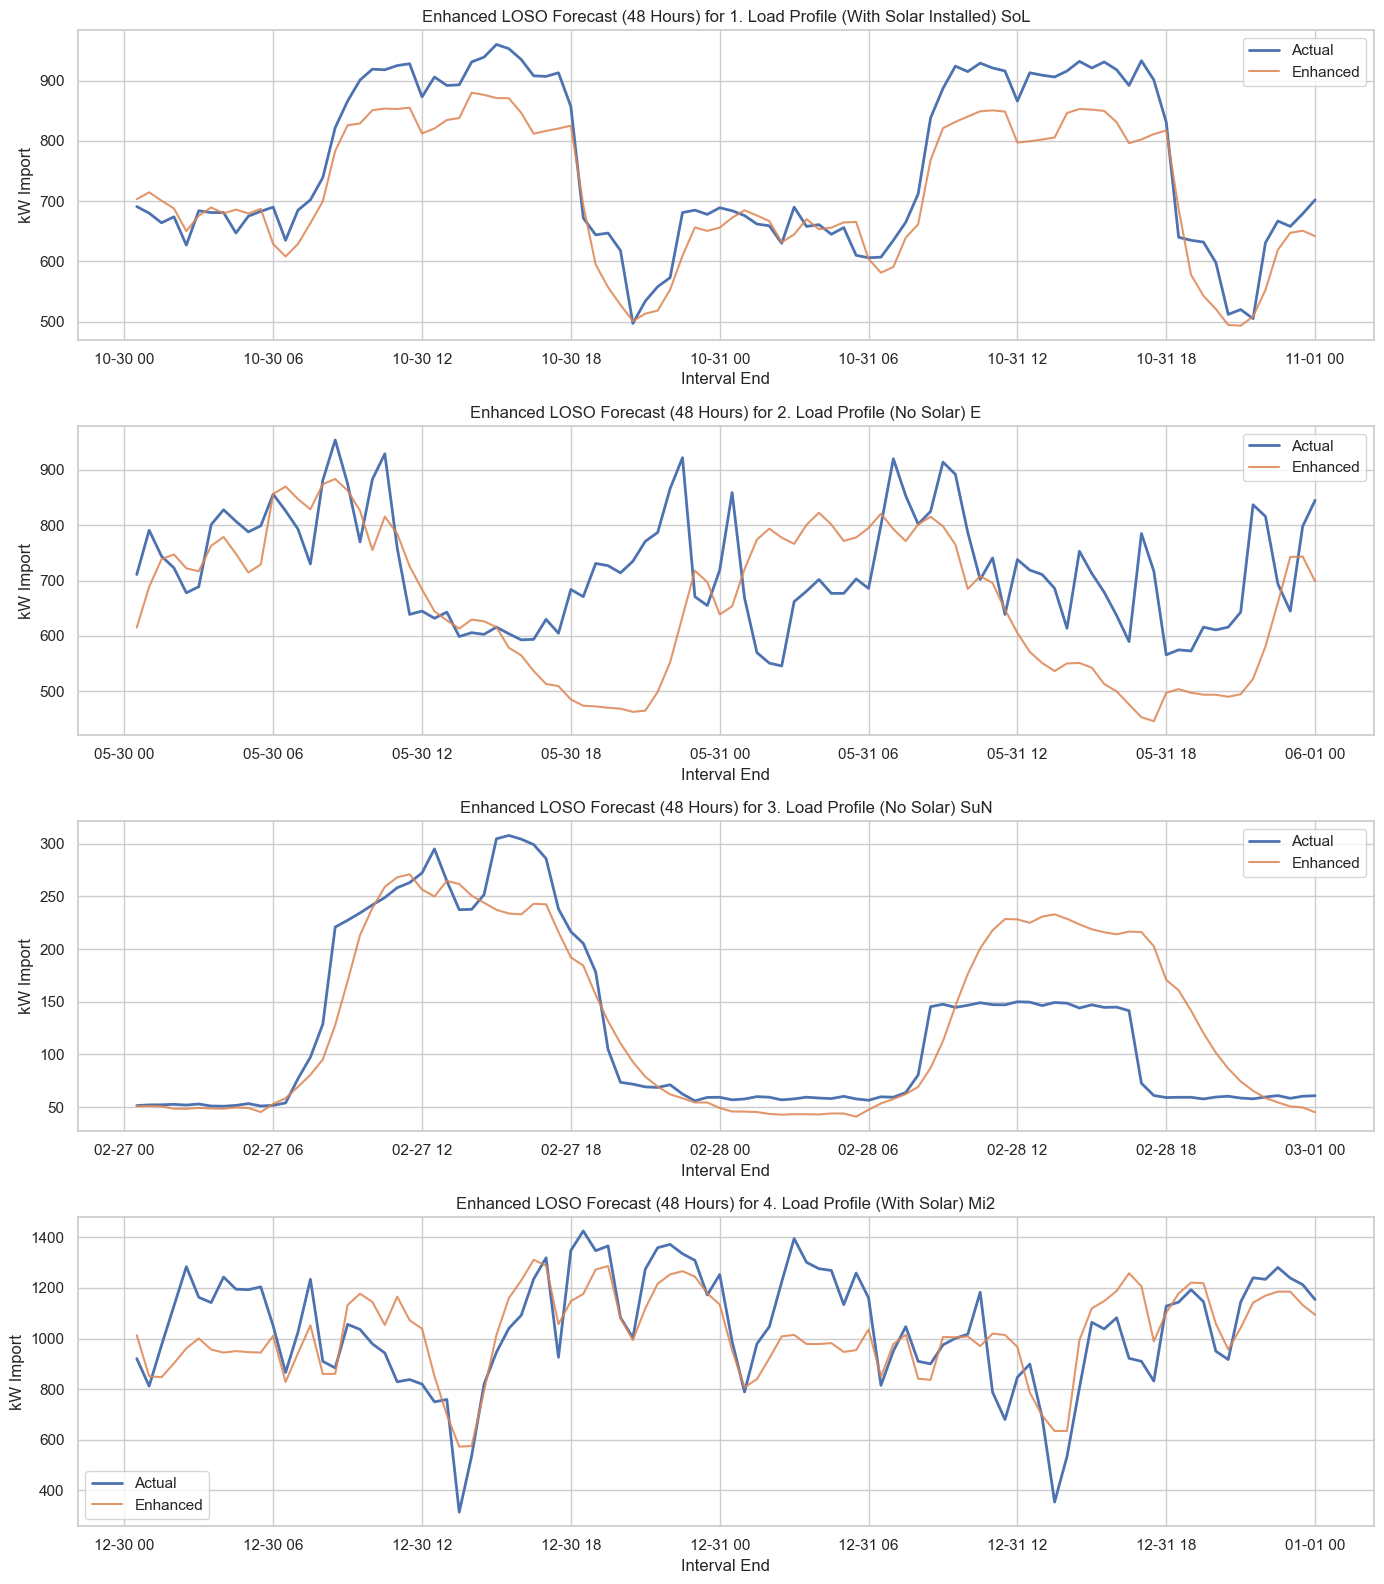

In [38]:
comparison_sites = [site for site in sorted(best_predictions.keys())]

fig, axes = plt.subplots(len(comparison_sites), 1, figsize=(14, 4 * len(comparison_sites)), sharex=False)
axes = np.atleast_1d(axes)

for ax, site_id in zip(axes, comparison_sites):
    comparison = best_predictions[site_id]
    ax.plot(comparison["interval_end"], comparison["actual_kw_import"], label="Actual", linewidth=2)
    ax.plot(comparison["interval_end"], comparison["enhanced_kw_import"], label="Enhanced", alpha=0.85)
    ax.set_title(f"Enhanced LOSO Forecast (48 Hours) for {site_id}")
    ax.set_xlabel("Interval End")
    ax.set_ylabel("kW Import")
    ax.legend()

plt.tight_layout()
plt.show()


Selected alpha on full training data: 100.0


,feature,coefficient,abs_coefficient
0,lag_1,0.136876,0.136876
1,lag_2,0.114220,0.114220
2,lag_3,0.110533,0.110533
3,delta_lag_1_2,0.108990,0.108990
4,rolling_max_4,0.100216,0.100216
5,rolling_mean_4,0.099825,0.099825
6,rolling_mean_48,0.087643,0.087643
7,lag_336,0.087394,0.087394
8,lag_48,0.081263,0.081263
9,rolling_mean_24,-0.078857,0.078857


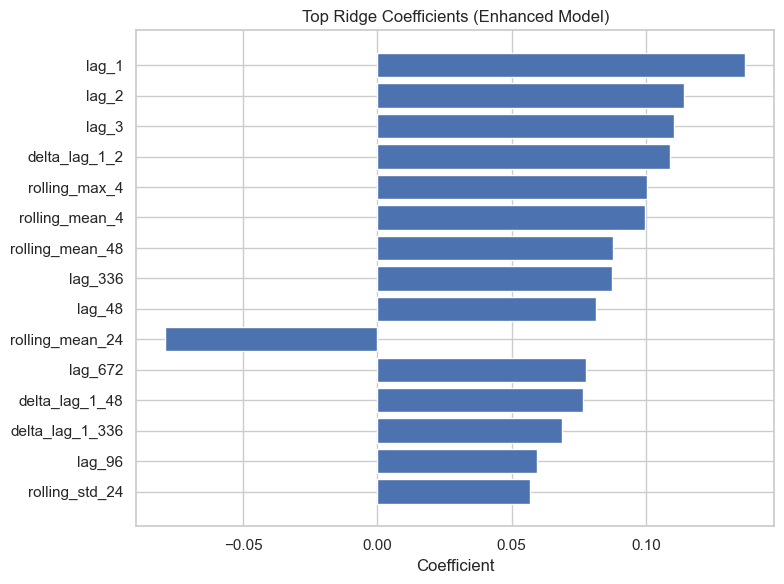

In [39]:
full_enhanced = fit_global_enhanced_ridge(clean_datasets.values(), n_splits=4)

ridge = full_enhanced.model.named_steps["ridge"]
coef_table = pd.DataFrame(
    {
        "feature": full_enhanced.feature_columns,
        "coefficient": ridge.coef_,
        "abs_coefficient": np.abs(ridge.coef_),
    }
).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

print(f"Selected alpha on full training data: {full_enhanced.alpha}")
display(coef_table.head(20))

top_n = 15
top = coef_table.head(top_n).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["coefficient"])
plt.title("Top Ridge Coefficients (Enhanced Model)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

In [40]:
# Lightweight latest-fold comparison for competition-safe model variants
variant_rows = []

for variant_key in ["A", "B", "C"]:
    for site_id, frame in clean_datasets.items():
        ordered = frame.sort_values("interval_end").reset_index(drop=True)
        cutoff = build_cutoffs(len(ordered), horizon=HORIZON)[-1]
        train_frame = ordered.iloc[:cutoff].copy()
        actual = ordered.iloc[cutoff : cutoff + HORIZON]["kw_import"].to_numpy()
        site_has_solar = bool(ordered["has_solar"].iloc[0])
        settings = site_evaluation_settings(site_has_solar)
        variant = variant_bundle(settings, variant_key)
        target_scale = site_scale_from_frame(train_frame)
        pooled_train_frames = [train_frame, *[clean_datasets[other_site] for other_site in site_ids if other_site != site_id]]

        enhanced = fit_global_enhanced_ridge(
            pooled_train_frames,
            alpha_grid=settings["alpha_grid"],
            n_splits=3,
            normalize_targets=True,
            **variant["fit_kwargs"],
        )
        regime_calibration = fit_regime_calibration(
            enhanced.model,
            train_frame,
            enhanced.feature_columns,
            window=336,
            normalize_targets=enhanced.normalize_targets,
            site_scale=target_scale,
        )
        blend_weight, _ = select_blend_weight(
            enhanced.model,
            train_frame,
            enhanced.feature_columns,
            horizon=HORIZON,
            candidates=settings["blend_candidates"],
            use_calibration_in_inner=True,
            normalize_targets=enhanced.normalize_targets,
            site_scale=target_scale,
            **variant["inner_forecast_kwargs"],
        )
        regime_blend_weight, _ = select_regime_blend_weight(
            enhanced.model,
            train_frame,
            enhanced.feature_columns,
            horizon=HORIZON,
            candidates=settings["blend_candidates"],
            use_calibration_in_inner=True,
            normalize_targets=enhanced.normalize_targets,
            site_scale=target_scale,
            default_weight=blend_weight,
            **variant["inner_forecast_kwargs"],
        )
        forecast = forecast_with_enhanced_model(
            model=enhanced.model,
            feature_columns=enhanced.feature_columns,
            target_frame=train_frame,
            horizon=HORIZON,
            blend_weight=regime_blend_weight,
            calibration=regime_calibration,
            normalize_targets=enhanced.normalize_targets,
            site_scale=target_scale,
            **variant["forecast_kwargs"],
        )

        component_column = "forecast_kw_import" if variant["component_model"] == "enhanced" else "seasonal_component"
        metrics = evaluate_forecast(actual, forecast[component_column].to_numpy())
        variant_rows.append(
            {
                "variant": variant["label"],
                "site_id": site_id,
                **metrics,
            }
        )

variant_results = pd.DataFrame(variant_rows)
variant_site_summary = summarize_model_metrics(variant_results, ["variant", "site_id"])
variant_overall_summary = summarize_model_metrics(variant_results, ["variant"])

print("Lightweight latest-fold variant comparison:")
display(variant_site_summary[["variant", "site_id", "rmse_kw", "wape_pct", "nrmse_by_peak_pct", "md_abs_error_kw"]])
display(variant_overall_summary[["variant", "rmse_kw", "wape_pct", "nrmse_by_peak_pct", "md_abs_error_kw"]])


Lightweight latest-fold variant comparison:


,variant,site_id,rmse_kw,wape_pct,nrmse_by_peak_pct,md_abs_error_kw
0,global_regime_current,1. Load Profile (With Solar Installed) SoL,34.736929,3.677791,3.723144,22.454167
1,global_regime_current,2. Load Profile (No Solar) E,129.363164,16.631261,14.061213,11.634793
2,global_regime_current,3. Load Profile (No Solar) SuN,69.878357,56.331191,46.601907,115.299693
3,global_regime_current,4. Load Profile (With Solar) Mi2,136.603335,9.933320,9.792354,45.300752
4,global_regime_softened,1. Load Profile (With Solar Installed) SoL,36.243767,3.805799,3.884648,21.298432
5,global_regime_softened,2. Load Profile (No Solar) E,129.363164,16.631261,14.061213,11.634793
6,global_regime_softened,3. Load Profile (No Solar) SuN,69.878357,56.331191,46.601907,115.299693
7,global_regime_softened,4. Load Profile (With Solar) Mi2,132.055401,9.802867,9.466337,43.078629
8,seasonal_anchor_baseline,1. Load Profile (With Solar Installed) SoL,23.135016,2.494852,2.479637,11.000000
9,seasonal_anchor_baseline,2. Load Profile (No Solar) E,123.793713,15.375224,13.455838,56.700000


,variant,rmse_kw,wape_pct,nrmse_by_peak_pct,md_abs_error_kw
0,global_regime_current,92.645446,21.643391,18.544654,48.672351
1,global_regime_softened,91.885172,21.642779,18.503526,47.827887
2,seasonal_anchor_baseline,97.091991,24.435121,21.139261,67.582429
